# `phoskintime.networkmodel` educational workflow: network-level dynamics

`networkmodel` fits network-level ODE dynamics across proteins, kinases, transcriptional inputs, and phosphosites. This notebook uses tiny synthetic frames and the current JAX/JAXopt/Diffrax utilities to demonstrate data-mode detection, adjacency handling, alpha/beta-style projection utilities, Diffrax-based ODE solving, local constrained optimization, ranked multistart solution ensembles, exports, and visualizations.

## Computational problem

A network model combines topology and kinetics. In full runs, an adjacency matrix maps kinase or regulatory influence onto protein/phosphosite states, and parameters control production, degradation, phosphorylation, dephosphorylation, and network scaling. The active backend solves:

$$
\frac{dY}{dt}=F(Y(t),\theta, A)
$$

and minimizes a scalar multimodal loss over observed mRNA, protein, and phosphosite measurements. The helper projection functions keep alpha-style contribution blocks on a simplex and beta-style blocks bounded/sum-controlled where those parameterizations are used.

In [1]:

from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "README.md").exists():
    REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT.parent))
import os
os.chdir(REPO_ROOT)

FAST_NOTEBOOK = True
RANDOM_SEED = 7

import json
from dataclasses import dataclass
from pathlib import Path
from types import SimpleNamespace

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import phoskintime.networkmodel as networkmodel_pkg
from networkmodel.backend import (
    detect_data_mode, validate_loss_data, solve_diffrax, multimodal_loss_from_trajectory,
    make_simple_objective, optimize_scalar_objective, project_alpha_blocks, project_beta_blocks,
)
from networkmodel.cache import prepare_fast_loss_data
from networkmodel.BayesianInference import InferenceContext, run_multistart
from networkmodel.mode_outputs import write_mode_metadata, write_scalar_result_tables, save_mode_plots
from networkmodel.dashboard_bundle import save_dashboard_bundle, load_dashboard_bundle

np.random.seed(RANDOM_SEED)
print("Imported phoskintime.networkmodel from:", networkmodel_pkg.__file__)


Imported phoskintime.networkmodel from: /home/abhinav/Documents/phoskintime/networkmodel/__init__.py


## Dummy topology and measurements

The minimal index object below mimics the fields consumed by `prepare_fast_loss_data`: protein-to-index mapping, site names, per-protein site counts, and flattened ODE state blocks. The interaction table is used for adjacency visualization and interpretation.

In [2]:

@dataclass
class DummyNetworkIndex:
    N: int = 2
    def __post_init__(self):
        self.p2i = {"P1": 0, "P2": 1}
        self.sites = [["S1"], ["S1"]]
        self.n_sites = np.asarray([1, 1], dtype=np.int32)
        self.n_states = np.asarray([2, 2], dtype=np.int32)
    def block(self, i: int) -> slice:
        start = i * 3
        return slice(start, start + 3)

idx = DummyNetworkIndex()
time_grid = np.asarray([0.0, 1.0, 2.0], dtype=float)
protein_df = pd.DataFrame({"protein": ["P1","P1","P2","P2"], "time": [0.0,1.0,0.0,1.0], "fc": [1.0,1.08,1.0,0.96], "w": [1,1,1,1]})
rna_df = pd.DataFrame({"protein": ["P1","P2"], "time": [1.0,1.0], "fc": [1.04,0.98]})
phospho_df = pd.DataFrame({"protein": ["P1","P2"], "psite": ["S1","S1"], "time": [1.0,1.0], "fc": [1.16,0.92]})
edge_df = pd.DataFrame({"kinase": ["P1", "P2"], "substrate": ["P2", "P1"], "site": ["S1", "S1"], "sign": [1, -1]})
display(protein_df); display(rna_df); display(phospho_df); display(edge_df)


,protein,time,fc,w
0,P1,0.0,1.00,1
1,P1,1.0,1.08,1
2,P2,0.0,1.00,1
3,P2,1.0,0.96,1


,protein,time,fc
0,P1,1.0,1.04
1,P2,1.0,0.98


,protein,psite,time,fc
0,P1,S1,1.0,1.16
1,P2,S1,1.0,0.92


,kinase,substrate,site,sign
0,P1,P2,S1,1
1,P2,P1,S1,-1


## Adjacency construction and alpha/beta-style constraints

The full network workflow builds sparse matrices from topology. For this small notebook, we show the equivalent adjacency table/heatmap and demonstrate the backend projection utilities. A high alpha in a block means a component receives most of that block's contribution; beta projection keeps bounded per-block combinations interpretable.

,P1,P2
P1,0.0,-1.0
P2,1.0,0.0


,raw_block,projected_sum_by_block
0,alpha,1.0
1,alpha,1.0
2,beta,1.0
3,beta,1.0


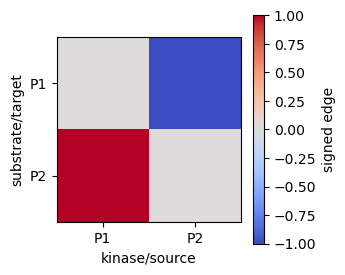

In [3]:

proteins = list(idx.p2i)
adj = pd.DataFrame(0.0, index=proteins, columns=proteins)
for _, row in edge_df.iterrows():
    adj.loc[row["substrate"], row["kinase"]] = row["sign"]
display(adj)
alpha_example = np.asarray(project_alpha_blocks(np.array([0.2, 0.9, 0.3, 0.1]), [0,0,1,1]))
beta_example = np.asarray(project_beta_blocks(np.array([-0.5, 1.8, 0.4, 0.9]), [0,0,1,1], lower=0.0, upper=1.0))
display(pd.DataFrame({"raw_block": ["alpha", "alpha", "beta", "beta"], "projected_sum_by_block": [alpha_example[:2].sum(), alpha_example[2:].sum(), beta_example[:2].sum(), beta_example[2:].sum()]}))

fig, ax = plt.subplots(figsize=(3.5, 3))
im = ax.imshow(adj.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(proteins)), proteins); ax.set_yticks(range(len(proteins)), proteins)
ax.set_xlabel("kinase/source"); ax.set_ylabel("substrate/target")
fig.colorbar(im, ax=ax, label="signed edge")
fig.tight_layout()


## Data validation and missing-modality handling

`prepare_fast_loss_data` converts tidy measurement frames to integer-index arrays used inside JAX losses. `detect_data_mode` determines which loss terms are active. The same mechanism handles missing phosphosite data or protein-only runs without padding fake observations.

In [4]:

loss_data = prepare_fast_loss_data(idx, protein_df, rna_df, phospho_df, time_grid)
mode = detect_data_mode(loss_data=loss_data)
validate_loss_data(loss_data, mode)
print(mode)

missing_cases = []
for case_name, rna_in, pho_in in [
    ("phosphosite_available", rna_df, phospho_df),
    ("phosphosite_missing", rna_df, pd.DataFrame(columns=["protein","psite","time","fc"])),
    ("protein_only_all_phosphosites_missing", pd.DataFrame(columns=["protein","time","fc"]), pd.DataFrame(columns=["protein","psite","time","fc"])),
]:
    ld = prepare_fast_loss_data(idx, protein_df, rna_in, pho_in, time_grid)
    dm = detect_data_mode(loss_data=ld)
    validate_loss_data(ld, dm)
    missing_cases.append({"case": case_name, "data_mode": dm.data_mode, "active_terms": ", ".join(dm.active_loss_terms)})
display(pd.DataFrame(missing_cases))


2026-06-09 11:06:14,926 - networkmodel.backend - INFO - [DataMode] Detected data mode: mrna+protein+phospho                                                                                             ⏱ 3.94 sec
2026-06-09 11:06:14,934 - networkmodel.backend - INFO - [DataMode] Available layers: mrna, protein, phospho                                                                                             ⏱ 3.94 sec
2026-06-09 11:06:14,936 - networkmodel.backend - INFO - [Objective] Active loss terms: mrna_loss, protein_loss, phospho_loss                                                                            ⏱ 3.94 sec
2026-06-09 11:06:14,937 - networkmodel.backend - INFO - [Objective] Skipped loss terms: none                                                                                                            ⏱ 3.94 sec
2026-06-09 11:06:14,943 - networkmodel.backend - INFO - [DataMode] Detected data mode: mrna+protein+phospho                                                 

DataMode(available_layers=('mrna', 'protein', 'phospho'), data_mode='mrna+protein+phospho', fit_mrna=True, fit_protein=True, fit_phospho=True)


,case,data_mode,active_terms
0,phosphosite_available,mrna+protein+phospho,"mrna_loss, protein_loss, phospho_loss"
1,phosphosite_missing,mrna+protein,"mrna_loss, protein_loss"
2,protein_only_all_phosphosites_missing,protein,protein_loss


## Diffrax solving, objective, and local optimization

For a compact CI-safe example we use `make_simple_objective`, which creates a scalar trajectory objective using the backend default RHS and Diffrax solver. In full network runs, the RHS includes the built topology; here the tiny default RHS keeps execution fast while exercising the real Diffrax/JAXopt path.

In [5]:

y0 = np.ones(6, dtype=float)  # two proteins × [mRNA, protein, phosphosite]
theta0 = np.asarray([0.10, 0.20], dtype=float)
lower = np.zeros_like(theta0)
upper = np.ones_like(theta0)
Y = solve_diffrax(y0, time_grid, params=theta0)
total_loss, parts = multimodal_loss_from_trajectory(Y, loss_data, mode, networkmodel_layout=True)
print("Initial multimodal loss:", float(total_loss), {k: float(v) for k, v in parts.items()})
objective = make_simple_objective(loss_data, mode, time_grid, y0=y0, networkmodel_layout=True)
params, opt_state, value = optimize_scalar_objective(objective, theta0, lower, upper, maxiter=3 if FAST_NOTEBOOK else 100, tol=1e-6)
print("Optimized params:", params, "objective:", value, "iterations:", getattr(opt_state, "iter_num", "unknown"))
param_df = pd.DataFrame({"parameter": ["rate_1", "rate_2"], "estimate": params, "lower": lower, "upper": upper})
display(param_df)


2026-06-09 11:06:24,042 - networkmodel.backend - INFO - [Optimizer] Selected optimizer backend: jaxopt.ProjectedGradient                                                                                ⏱ 13.05 sec
2026-06-09 11:06:24,047 - networkmodel.backend - INFO - [Constraints] Kinetic parameters use bound projection; fixed parameters are restored after each projection.                                     ⏱ 13.06 sec


Initial multimodal loss: 0.029909579382669842 {'protein': 0.003934400457360978, 'mrna': 0.004028970094044523, 'phospho': 0.02194620883126434}
INFO: jaxopt.ProximalGradient: Iter: 1 Distance btw Iterates (stopping criterion): 0.0011646830536967 Stepsize:2.0 
INFO: jaxopt.ProximalGradient: Iter: 2 Distance btw Iterates (stopping criterion): 0.0011649242979037912 Stepsize:4.0 
INFO: jaxopt.ProximalGradient: Iter: 3 Distance btw Iterates (stopping criterion): 0.0013296423187294168 Stepsize:8.0 


2026-06-09 11:06:55,868 - networkmodel.backend - INFO - [Optimizer] Convergence status: iterations=3 final_objective=0.026078907 grad_norm=0.0023328941                                                 ⏱ 44.88 sec


Optimized params: [0.11762304 0.19966642] objective: 0.026078907295906055 iterations: 3


,parameter,estimate,lower,upper
0,rate_1,0.117623,0.0,1.0
1,rate_2,0.199666,0.0,1.0


## Ranked multistart solution ensemble and exports

The inference utility repeats local optimization from deterministic starts, ranks by scalar objective, and writes summary/parameter CSVs plus multistart plots.

In [6]:

output_dir = REPO_ROOT / "notebooks" / "outputs" / "networkmodel"
output_dir.mkdir(parents=True, exist_ok=True)
ctx = InferenceContext(objective, theta0, lower, upper, mode, output_dir, parameter_names=("rate_1", "rate_2"), maxiter=2 if FAST_NOTEBOOK else 50)
ensemble = run_multistart(ctx, n_starts=2 if FAST_NOTEBOOK else 8, seed=RANDOM_SEED, max_workers=1)
display(ensemble["summary"].sort_values("final_objective"))
display(ensemble["parameters"])
write_mode_metadata(output_dir, mode, objective_value=value)
result_paths = write_scalar_result_tables(output_dir, mode, [value])
legacy_path = result_paths.get("legacy_objective")
if legacy_path is not None and legacy_path.exists():
    legacy_path.unlink()
print({k: str(v.name) for k, v in result_paths.items() if k != "legacy_objective"})


2026-06-09 11:06:56,010 - networkmodel.BayesianInference - INFO - [Inference] JAX/XLA multistart strategy: {'requested_workers': 1, 'effective_workers': 1, 'xla_flags': '--xla_cpu_multi_thread_eigen=false intra_op_parallelism_threads=1', 'omp_num_threads': '1'}⏱ 44.89 sec
2026-06-09 11:06:56,016 - networkmodel.BayesianInference - INFO - [Optimizer] Selected optimizer backend: jaxopt.ProjectedGradient                                                                      ⏱ 44.90 sec
2026-06-09 11:06:56,018 - networkmodel.BayesianInference - INFO - [Constraints] Kinetic parameters use bound projection; fixed parameters are restored after each projection.                           ⏱ 44.90 sec


INFO: jaxopt.ProximalGradient: Iter: 1 Distance btw Iterates (stopping criterion): 0.0011646830536967 Stepsize:2.0 
INFO: jaxopt.ProximalGradient: Iter: 2 Distance btw Iterates (stopping criterion): 0.0011649242979037912 Stepsize:4.0 


2026-06-09 11:07:11,696 - networkmodel.BayesianInference - INFO - [Optimizer] Convergence status: iterations=2 final_objective=0.026103713 grad_norm=0.0023307989                                       ⏱ 1.01 min
2026-06-09 11:07:11,699 - networkmodel.BayesianInference - INFO - [Optimizer] Selected optimizer backend: jaxopt.ProjectedGradient                                                                      ⏱ 1.01 min
2026-06-09 11:07:11,701 - networkmodel.BayesianInference - INFO - [Constraints] Kinetic parameters use bound projection; fixed parameters are restored after each projection.                           ⏱ 1.01 min


INFO: jaxopt.ProximalGradient: Iter: 1 Distance btw Iterates (stopping criterion): 0.0011545651382253387 Stepsize:2.0 
INFO: jaxopt.ProximalGradient: Iter: 2 Distance btw Iterates (stopping criterion): 0.0011542823524186448 Stepsize:4.0 


2026-06-09 11:07:27,703 - networkmodel.BayesianInference - INFO - [Optimizer] Convergence status: iterations=2 final_objective=0.024945971 grad_norm=0.0023074219                                       ⏱ 1.28 min


,start_id,seed,convergence_status,success,failure_reason,final_objective,active_loss_terms,number_of_iterations,solver_status,optimizer_status,runtime_seconds,data_mode,available_layers,selected_best
1,1,8,converged,True,,0.024946,"mrna_loss,protein_loss,phospho_loss",2,diffrax,jaxopt.ProjectedGradient,16.005972,mrna+protein+phospho,"mrna,protein,phospho",True
0,0,7,converged,True,,0.026104,"mrna_loss,protein_loss,phospho_loss",2,diffrax,jaxopt.ProjectedGradient,15.682828,mrna+protein+phospho,"mrna,protein,phospho",False


,start_id,seed,success,selected_best,rate_1,rate_2
0,0,7,True,False,0.106988,0.199868
1,1,8,True,True,0.632007,0.896759


{'scalar_objective': 'scalar_objective.csv', 'metadata': 'mode_metadata.json'}


## Fitted dynamics and visualization

The fitted trajectory is converted into tidy prediction tables. Built-in `save_mode_plots` writes simple layer plots; notebook-level figures add adjacency and ranked-loss views.

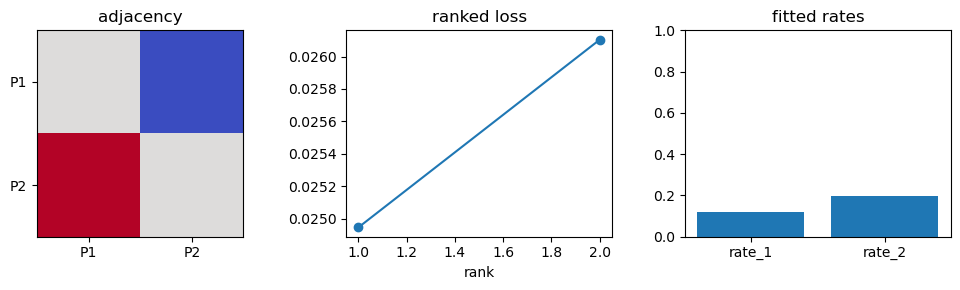

Dashboard bundle mode: mrna+protein+phospho
Saved files: ['.gitkeep', 'dashboard_bundle.pkl', 'mode_metadata.json', 'mrna_prediction.csv', 'mrna_prediction.png', 'network_summary_plots.png', 'optimization', 'phospho_prediction.csv', 'phospho_prediction.png', 'plots', 'protein_prediction.csv', 'protein_prediction.png', 'scalar_objective.csv']


In [7]:

Y_fit = np.asarray(solve_diffrax(y0, time_grid, params=params))
predictions = {
    "mrna": pd.DataFrame({"time": time_grid, "pred_fc": Y_fit[:, 0]}),
    "protein": pd.DataFrame({"time": time_grid, "pred_fc": Y_fit[:, 1]}),
    "phospho": pd.DataFrame({"time": time_grid, "pred_fc": Y_fit[:, 2]}),
}
plot_paths = save_mode_plots(output_dir, mode, predictions)
for layer, df in predictions.items():
    df.to_csv(output_dir / f"{layer}_prediction.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(adj.values, cmap="coolwarm", vmin=-1, vmax=1); axes[0].set_title("adjacency")
axes[0].set_xticks(range(len(proteins)), proteins); axes[0].set_yticks(range(len(proteins)), proteins)
summary_sorted = ensemble["summary"].sort_values("final_objective")
axes[1].plot(range(1, len(summary_sorted)+1), summary_sorted["final_objective"], "o-"); axes[1].set_title("ranked loss"); axes[1].set_xlabel("rank")
axes[2].bar(param_df["parameter"], param_df["estimate"]); axes[2].set_title("fitted rates"); axes[2].set_ylim(0, 1)
fig.tight_layout(); fig.savefig(output_dir / "network_summary_plots.png", dpi=200); plt.show()

save_dashboard_bundle(output_dir, args=SimpleNamespace(dummy_notebook=True),
    res=SimpleNamespace(X=np.asarray([params]), F=np.asarray([[value]]), objective_value=value, params=params, state=None, data_mode=mode, loss_breakdown={}),
    slices={}, xl=lower, xu=upper, defaults={}, lambdas={}, solver_times=time_grid,
    df_prot=protein_df, df_rna=rna_df, df_pho=phospho_df)
bundle = load_dashboard_bundle(output_dir)
print("Dashboard bundle mode:", bundle["data_mode"])
print("Saved files:", sorted(p.name for p in output_dir.iterdir()))


## Interpretation and end-to-end summary

- **Inputs:** protein, mRNA, phosphosite, and kinase-substrate network tables.
- **Preprocessing:** tidy frames became JAX-ready loss arrays with explicit data-mode validation.
- **Network handling:** adjacency was built for interpretation; alpha/beta projection utilities showed the constraints used by block-structured parameterizations.
- **Solving:** Diffrax-based ODE solving and JAXopt local optimization estimated scalar parameters.
- **Outputs:** ranked multistart solution ensemble, parameter CSVs, layer prediction CSVs, mode metadata, dashboard bundle, and plots.
- **Difference from protwise:** `protwise` fits one protein/site local model at a time, while `networkmodel` is designed to fit coupled network-level dynamics across proteins and interaction topology.